# Individual Comparison on HCP

This notebook reproduces the result visualizations for the HCP individual-parcellation comparison section. It uses the precomputed result tables under `results/4.hcp` and does not require the lab-local data paths used by `indiv_eval_hcp.py` to generate the original parcellations/evaluations.

This result section focuses on the comparison between individual parcellations derived from the HBP rest prior and the HBP fusion prior.

Figures covered here:
- Figure 4e-f: task inhomogeneity and DCBC on HCP task contrasts.
- Figure 4g: resting-state homogeneity on HCP rest time series.
- Figure 4h: task-domain-wise inhomogeneity on HCP task contrasts.


In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from scipy import stats

sb.set_theme(style="ticks", context="talk")
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.linewidth"] = 1.2


In [6]:
def find_repo_root(start=Path.cwd()):
    for path in [start, *start.parents]:
        if (path / "train_group.py").exists() and (path / "results").exists():
            return path
    raise FileNotFoundError("Could not locate the IndividualParcellation repo root.")


REPO_ROOT = find_repo_root()
RESULT_DIR = REPO_ROOT / "results" / "4.hcp"
OUTPUT_DIR = RESULT_DIR / "figures"
SAVE_FIGURES = False

if SAVE_FIGURES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TASK_FILE = RESULT_DIR / "eval_indiv-rest_vs_fusion-HCP200_1-2run_K-17_test_on_HCPtask-contrast.tsv"
REST_FILE = RESULT_DIR / "eval_indiv-rest_vs_fusion-HCP200_1-2run_K-17_test_on_HCPrest-Tseries.tsv"
DOMAIN_FILE = RESULT_DIR / "eval_indiv-rest_vs_fusion-HCP200_1-2run_K-17_test_on_HCPtask-contrast_domain-wise.tsv"
DICE_FILE = RESULT_DIR / "dice_within_vs_between_HCP_rest1run_K-17.tsv"
REST_PAIRWISE_DICE_FILE = RESULT_DIR / "dice_pair-wise_REST+HCPrest-1run1_vs_1run2.npy"
FUSION_PAIRWISE_DICE_FILE = RESULT_DIR / "dice_pair-wise_FUSION+HCPrest-1run1_vs_1run2.npy"

RESULT_DIR


PosixPath('/home/dzhi/Workspace/IndividualParcellation/results/4.hcp')

In [7]:
task_eval_raw = pd.read_csv(TASK_FILE, sep="\t")
rest_eval_raw = pd.read_csv(REST_FILE, sep="\t")
domain_eval_raw = pd.read_csv(DOMAIN_FILE, sep="\t")

# This result section focuses on HBP rest prior versus HBP fusion prior.
MODEL_ORDER = ["rest", "fusion"]
task_eval = task_eval_raw[task_eval_raw["type"].isin(MODEL_ORDER)].copy()
rest_eval = rest_eval_raw[rest_eval_raw["type"].isin(MODEL_ORDER)].copy()
domain_eval = domain_eval_raw[domain_eval_raw["type"].isin(MODEL_ORDER)].copy()

for df in [task_eval, rest_eval, domain_eval]:
    df["type"] = pd.Categorical(df["type"], categories=MODEL_ORDER, ordered=True)
    df["train_sess"] = pd.Categorical(df["train_sess"], categories=["run-1", "run-2"], ordered=True)

summary = pd.DataFrame({
    "table": ["task contrast", "rest Tseries", "task contrast domain-wise"],
    "rows": [len(task_eval), len(rest_eval), len(domain_eval)],
    "subjects": [task_eval.subj_num.nunique(), rest_eval.subj_num.nunique(), domain_eval.subj_num.nunique()],
})
summary


,table,rows,subjects
0,task contrast,800,200
1,rest Tseries,1600,200
2,task contrast domain-wise,2800,200


In [8]:
# Plot style copied from notebooks/res4.ipynb.
HUE_ORDER = ["rest", "fusion"]
REST_FUSION_ORDER = HUE_ORDER
PALETTE = {
    "rest": "#EE6677",
    "fusion": "#009E73",
}
BAR_WIDTH = 0.52
EDGE_COLOR = "black"
EDGE_WIDTH = 1.0
CAPSIZE = 0.15


def stroke_bars(ax):
    for bar in ax.patches:
        bar.set_edgecolor(EDGE_COLOR)
        bar.set_linewidth(EDGE_WIDTH)


def move_legend_outside(ax):
    handles, labels = ax.get_legend_handles_labels()
    if not handles:
        return
    ax.legend(handles[:len(HUE_ORDER)], labels[:len(HUE_ORDER)],
              title="Prior", frameon=False,
              loc="upper left", bbox_to_anchor=(1.02, 1.0),
              borderaxespad=0)


def style_axis(ax, title, ylabel=None, ylim=None, legend=True):
    stroke_bars(ax)
    ax.set_title(title)
    ax.set_xlabel("")
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.tick_params(axis="x", rotation=45)
    if legend:
        move_legend_outside(ax)
    elif ax.get_legend() is not None:
        ax.get_legend().remove()
    sb.despine(ax=ax)


def barplot_metric(data, x, y, hue, ax, hue_order, order=None, ylim=None,
                   title=None, ylabel=None, legend=True):
    sb.barplot(
        data=data,
        x=x,
        y=y,
        hue=hue,
        hue_order=hue_order,
        order=order,
        errorbar="se",
        capsize=CAPSIZE,
        width=BAR_WIDTH,
        palette=PALETTE,
        dodge=True,
        ax=ax,
    )
    style_axis(ax, title or y, ylabel=ylabel, ylim=ylim, legend=legend)
    return ax


In [9]:
def subject_metric(df, metric, type_name, train_sess=None, **filters):
    sub = df[df["type"].astype(str) == type_name].copy()
    if train_sess is not None:
        sub = sub[sub["train_sess"].astype(str) == train_sess]
    for key, value in filters.items():
        sub = sub[sub[key] == value]
    return sub.groupby("subj_num")[metric].mean()


def paired_ttest(df, metric, type_a, type_b, train_sess=None, label=None, **filters):
    a = subject_metric(df, metric, type_a, train_sess=train_sess, **filters)
    b = subject_metric(df, metric, type_b, train_sess=train_sess, **filters)
    common = a.index.intersection(b.index)
    a = a.loc[common].sort_index()
    b = b.loc[common].sort_index()
    result = stats.ttest_rel(a, b)
    return {
        "comparison": label or f"{type_a} vs {type_b}",
        "metric": metric,
        "train_sess": train_sess or "all",
        "n": len(common),
        f"mean_{type_a}": float(a.mean()),
        f"mean_{type_b}": float(b.mean()),
        f"mean_diff_{type_b}-{type_a}": float((b - a).mean()),
        "t": float(result.statistic),
        "p": float(result.pvalue),
    }


def paired_ttest_table(df, metrics, sessions=("run-1", "run-2")):
    rows = []
    for metric in metrics:
        for train_sess in sessions:
            rows.append(paired_ttest(df, metric, "rest", "fusion", train_sess,
                                     label="rest vs fusion"))
    out = pd.DataFrame(rows)
    numeric_cols = out.select_dtypes(include="number").columns
    out[numeric_cols] = out[numeric_cols].round(6)
    return out


## Figures 4e-f: task inhomogeneity and DCBC

Individual parcellations were trained from 1 or 2 HCP resting-state runs using either the HBP rest prior or the HBP fusion prior, then evaluated on HCP task contrasts.


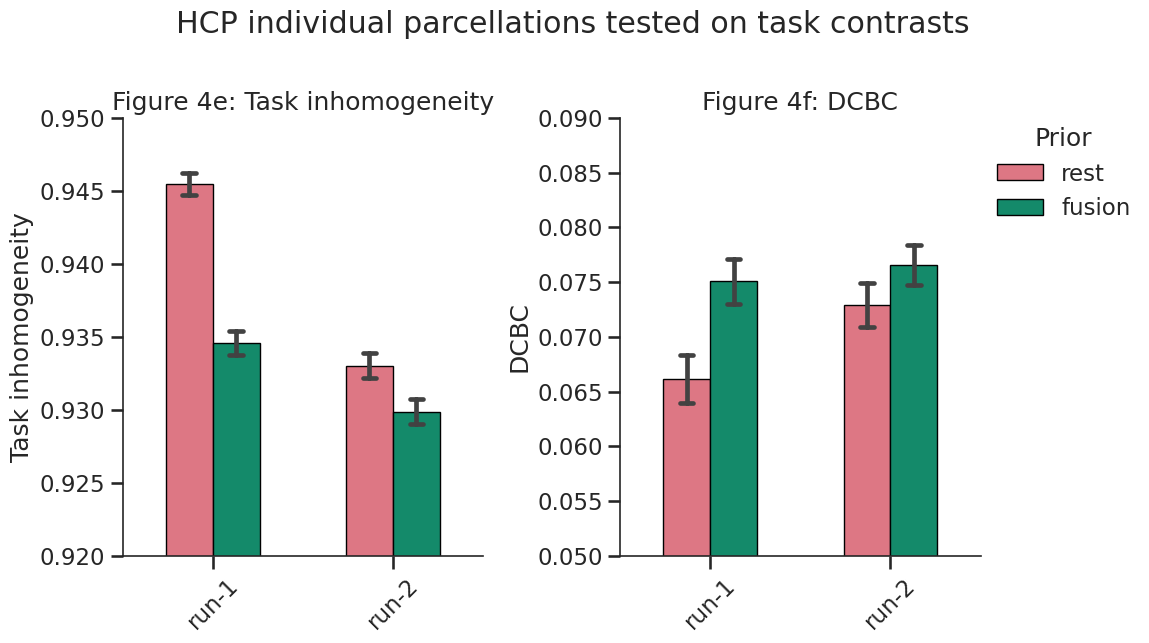

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True)

barplot_metric(
    task_eval,
    x="train_sess",
    y="inhomo_indiv",
    hue="type",
    hue_order=HUE_ORDER,
    order=["run-1", "run-2"],
    ylim=(0.92, 0.95),
    title="Figure 4e: Task inhomogeneity",
    ylabel="Task inhomogeneity",
    legend=False,
    ax=axes[0],
)

barplot_metric(
    task_eval,
    x="train_sess",
    y="dcbc_indiv",
    hue="type",
    hue_order=HUE_ORDER,
    order=["run-1", "run-2"],
    ylim=(0.05, 0.09),
    title="Figure 4f: DCBC",
    ylabel="DCBC",
    legend=True,
    ax=axes[1],
)

fig.suptitle("HCP individual parcellations tested on task contrasts", y=1.02)
fig.subplots_adjust(wspace=0.38, right=0.84, top=0.84)

if SAVE_FIGURES:
    fig.savefig(OUTPUT_DIR / "Figure_4ef_task_inhomogeneity_dcbc.png", dpi=300, bbox_inches="tight")
plt.show()


In [11]:
task_ttests = paired_ttest_table(task_eval, ["inhomo_indiv", "dcbc_indiv"])
task_ttests


,comparison,metric,train_sess,n,mean_rest,mean_fusion,mean_diff_fusion-rest,t,p
0,rest vs fusion,inhomo_indiv,run-1,200,0.945483,0.934565,-0.010917,37.754999,0.0
1,rest vs fusion,inhomo_indiv,run-2,200,0.933018,0.929881,-0.003137,36.501087,0.0
2,rest vs fusion,dcbc_indiv,run-1,200,0.066151,0.075064,0.008912,-11.336345,0.0
3,rest vs fusion,dcbc_indiv,run-2,200,0.072866,0.076559,0.003693,-6.021574,0.0


## Figure 4g: resting-state homogeneity

The rest table has two held-out test runs. For statistical tests, values are averaged within subject, prior, and training-session before paired tests.


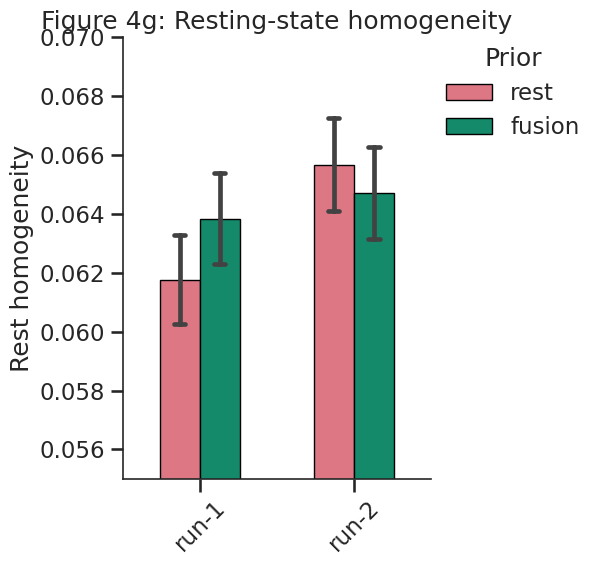

In [12]:
rest_plot = (
    rest_eval
    .groupby(["subj_num", "type", "train_sess"], observed=True, as_index=False)
    .mean(numeric_only=True)
)

fig, ax = plt.subplots(1, 1, figsize=(7.6, 6))
barplot_metric(
    rest_plot,
    x="train_sess",
    y="homo_indiv",
    hue="type",
    hue_order=HUE_ORDER,
    order=["run-1", "run-2"],
    ylim=(0.055, 0.07),
    title="Figure 4g: Resting-state homogeneity",
    ylabel="Rest homogeneity",
    legend=True,
    ax=ax,
)
fig.tight_layout(rect=[0, 0, 0.84, 1])

if SAVE_FIGURES:
    fig.savefig(OUTPUT_DIR / "Figure_4g_rest_homogeneity.png", dpi=300, bbox_inches="tight")
plt.show()


In [13]:
rest_ttests = paired_ttest_table(rest_eval, ["homo_indiv"])
rest_ttests


,comparison,metric,train_sess,n,mean_rest,mean_fusion,mean_diff_fusion-rest,t,p
0,rest vs fusion,homo_indiv,run-1,200,0.061768,0.063837,0.002069,-20.647155,0.0
1,rest vs fusion,homo_indiv,run-2,200,0.065678,0.064712,-0.000966,28.327494,0.0


## Figure 4h: task-domain-wise inhomogeneity

Task-domain-wise evaluation compares HBP rest and HBP fusion priors for the 1-run setting across the seven HCP task domains.


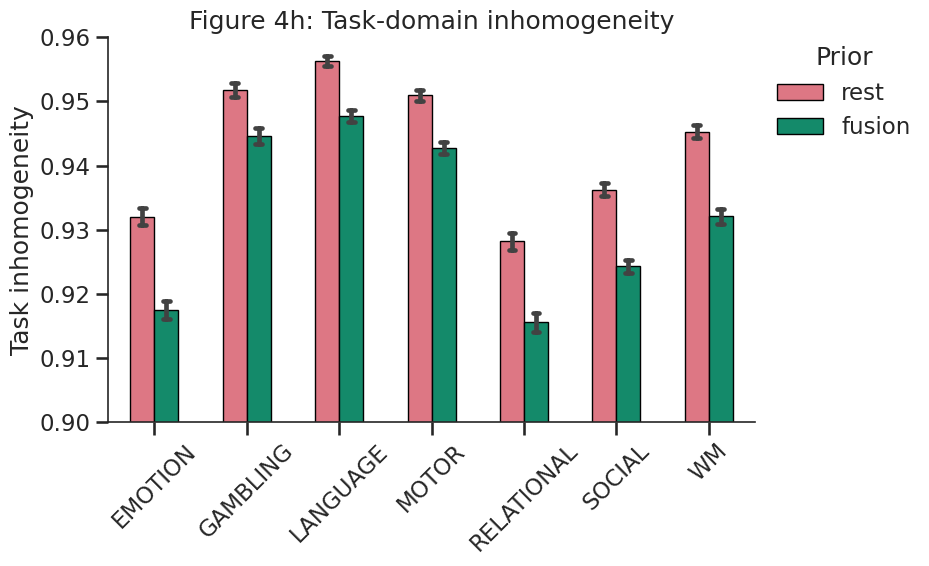

In [14]:
TASK_ORDER = ["EMOTION", "GAMBLING", "LANGUAGE", "MOTOR", "RELATIONAL", "SOCIAL", "WM"]
domain_plot = domain_eval.copy()
domain_plot["task_name"] = pd.Categorical(domain_plot["task_name"], categories=TASK_ORDER, ordered=True)
domain_plot["type"] = pd.Categorical(domain_plot["type"].astype(str), categories=REST_FUSION_ORDER, ordered=True)

fig, ax = plt.subplots(1, 1, figsize=(11, 6))
sb.barplot(
    data=domain_plot,
    x="task_name",
    y="inhomo_indiv",
    hue="type",
    hue_order=REST_FUSION_ORDER,
    order=TASK_ORDER,
    errorbar="se",
    capsize=CAPSIZE,
    width=BAR_WIDTH,
    palette=PALETTE,
    dodge=True,
    ax=ax,
)

style_axis(ax, "Figure 4h: Task-domain inhomogeneity",
           ylabel="Task inhomogeneity", ylim=(0.90, 0.96), legend=True)
fig.tight_layout(rect=[0, 0, 0.88, 1])

if SAVE_FIGURES:
    fig.savefig(OUTPUT_DIR / "Figure_4h_task_domain_inhomogeneity.png", dpi=300, bbox_inches="tight")
plt.show()


In [15]:
domain_rows = []
for task_name in TASK_ORDER:
    domain_rows.append(paired_ttest(domain_eval, "inhomo_indiv", "rest", "fusion",
                                    train_sess="run-1", task_name=task_name,
                                    label=f"rest vs fusion: {task_name}"))
domain_ttests = pd.DataFrame(domain_rows)
numeric_cols = domain_ttests.select_dtypes(include="number").columns
domain_ttests[numeric_cols] = domain_ttests[numeric_cols].round(6)
domain_ttests


,comparison,metric,train_sess,n,mean_rest,mean_fusion,mean_diff_fusion-rest,t,p
0,rest vs fusion: EMOTION,inhomo_indiv,run-1,200,0.932003,0.917486,-0.014516,30.775087,0.0
1,rest vs fusion: GAMBLING,inhomo_indiv,run-1,200,0.951799,0.944610,-0.007188,22.251860,0.0
2,rest vs fusion: LANGUAGE,inhomo_indiv,run-1,200,0.956377,0.947711,-0.008666,22.041164,0.0
3,rest vs fusion: MOTOR,inhomo_indiv,run-1,200,0.950938,0.942735,-0.008203,30.625495,0.0
4,rest vs fusion: RELATIONAL,inhomo_indiv,run-1,200,0.928233,0.915566,-0.012667,27.384494,0.0
5,rest vs fusion: SOCIAL,inhomo_indiv,run-1,200,0.936253,0.924289,-0.011964,32.880127,0.0
6,rest vs fusion: WM,inhomo_indiv,run-1,200,0.945305,0.932118,-0.013187,32.672283,0.0


## Figure 4i: within- versus between-individual parcellation similarity

This panel compares Dice similarity within individual subjects across sessions and between different individuals, separately for rest-prior and fusion-prior individual parcellations trained from one HCP resting-state run.


In [16]:
dice_eval = pd.read_csv(DICE_FILE, sep="\t")
dice_eval = dice_eval[dice_eval["type"].isin(HUE_ORDER)].copy()
dice_eval["type"] = pd.Categorical(dice_eval["type"], categories=HUE_ORDER, ordered=True)
dice_eval["w/b"] = pd.Categorical(dice_eval["w/b"], categories=["within", "between"], ordered=True)
dice_eval = dice_eval[dice_eval["networks"] == "all"].copy()

dice_summary = (
    dice_eval
    .groupby(["w/b", "type"], observed=True)["dice"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
dice_summary


,w/b,type,mean,std,count
0,within,rest,0.623974,0.049069,200
1,within,fusion,0.695450,0.042224,200
2,between,rest,0.518832,0.028948,19900
3,between,fusion,0.586142,0.025283,19900


/tmp/ipykernel_721871/1489682248.py:22: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(["Within individual", "Between individuals"])


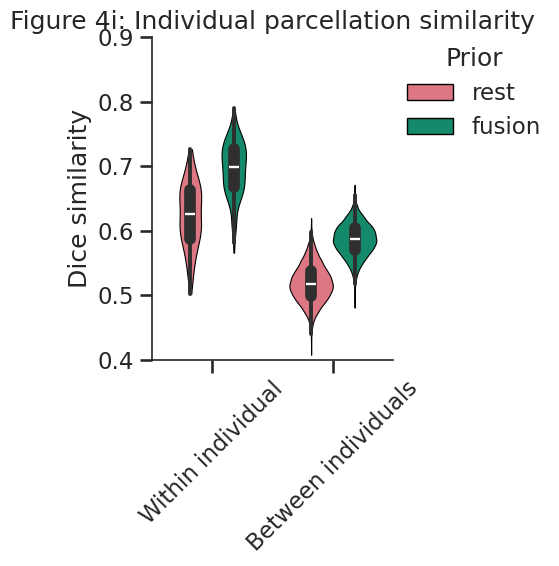

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(6.6, 6))
sb.violinplot(
    data=dice_eval,
    x="w/b",
    y="dice",
    order=["within", "between"],
    hue="type",
    hue_order=HUE_ORDER,
    inner="box",
    width=0.72,
    palette=PALETTE,
    cut=0,
    ax=ax,
)

for collection in ax.collections:
    collection.set_edgecolor("black")
    collection.set_linewidth(0.8)

style_axis(ax, "Figure 4i: Individual parcellation similarity",
           ylabel="Dice similarity", ylim=(0.4, 0.9), legend=True)
ax.set_xticklabels(["Within individual", "Between individuals"])
fig.tight_layout(rect=[0, 0, 0.82, 1])

if SAVE_FIGURES:
    fig.savefig(OUTPUT_DIR / "Figure_4i_within_between_similarity.png", dpi=300, bbox_inches="tight")
plt.show()


In [18]:
def dice_group(df, type_name, wb):
    return (
        df[(df["type"].astype(str) == type_name) & (df["w/b"].astype(str) == wb)]
        .groupby("subj")["dice"]
        .mean()
    )

rest_within = dice_group(dice_eval, "rest", "within")
rest_between = dice_group(dice_eval, "rest", "between")
fusion_within = dice_group(dice_eval, "fusion", "within")
fusion_between = dice_group(dice_eval, "fusion", "between")

rows = []
for label, a, b, test in [
    ("rest: within vs between", rest_within, rest_between, "welch"),
    ("fusion: within vs between", fusion_within, fusion_between, "welch"),
    ("within: rest vs fusion", rest_within, fusion_within, "paired"),
    ("between: rest vs fusion", rest_between, fusion_between, "paired"),
]:
    if test == "paired":
        common = a.index.intersection(b.index)
        result = stats.ttest_rel(a.loc[common].sort_index(), b.loc[common].sort_index())
        n = len(common)
    else:
        result = stats.ttest_ind(a, b, equal_var=False)
        n = min(len(a), len(b))
    rows.append({
        "comparison": label,
        "test": test,
        "n": n,
        "mean_a": float(a.mean()),
        "mean_b": float(b.mean()),
        "t": float(result.statistic),
        "p": float(result.pvalue),
    })

dice_ttests = pd.DataFrame(rows)
numeric_cols = dice_ttests.select_dtypes(include="number").columns
dice_ttests[numeric_cols] = dice_ttests[numeric_cols].round(6)
dice_ttests


,comparison,test,n,mean_a,mean_b,t,p
0,rest: within vs between,welch,200,0.623974,0.518832,30.250044,0.0
1,fusion: within vs between,welch,200,0.695450,0.586142,36.544975,0.0
2,within: rest vs fusion,paired,200,0.623974,0.695450,-58.803076,0.0
3,between: rest vs fusion,paired,19900,0.518832,0.586142,-851.719287,0.0


## (Supp Figure 6c,d) Prediction accuracy from run-wise pairwise Dice matrices

The pairwise Dice matrices compare each subject's run-1 parcellation against every subject's run-2 parcellation. Prediction accuracy is the fraction of subjects whose own paired run has the maximum Dice coefficient.

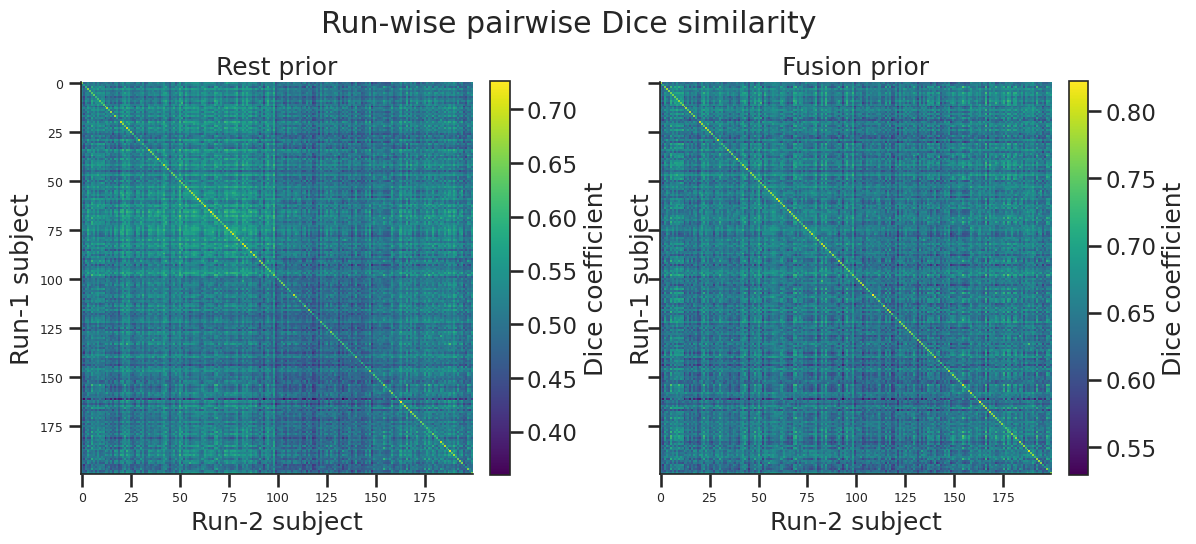

In [19]:
pairwise_dice = {
    "rest": np.load(REST_PAIRWISE_DICE_FILE),
    "fusion": np.load(FUSION_PAIRWISE_DICE_FILE),
}

for prior, mat in pairwise_dice.items():
    if mat.ndim != 2 or mat.shape[0] != mat.shape[1]:
        raise ValueError(f"{prior} pairwise Dice matrix must be square; got {mat.shape}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), sharex=True, sharey=True)
for ax, prior in zip(axes, HUE_ORDER):
    mat = pairwise_dice[prior]
    im = ax.imshow(
        mat,
        vmin=np.nanmin(mat),
        vmax=np.nanmax(mat),
        cmap="viridis",
        interpolation="nearest",
        aspect="equal",
    )
    ax.set_title(f"{prior.capitalize()} prior")
    ax.set_xlabel("Run-2 subject")
    ax.set_ylabel("Run-1 subject")
    ax.tick_params(axis="both", labelsize=9)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Dice coefficient")
    sb.despine(ax=ax, left=False, bottom=False)

fig.subplots_adjust(wspace=0.35, top=0.83)
fig.suptitle("Run-wise pairwise Dice similarity", y=0.95)

if SAVE_FIGURES:
    fig.savefig(OUTPUT_DIR / "pairwise_run_dice_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
def identification_accuracy(mat):
    n_run1, n_run2 = mat.shape
    if n_run1 != n_run2:
        raise ValueError(f"Pairwise Dice matrix must be square; got {mat.shape}")
    subject_idx = np.arange(n_run1)
    run1_predict_run2 = np.argmax(mat, axis=1)
    run2_predict_run1 = np.argmax(mat, axis=0)
    acc_1_to_2 = np.mean(run1_predict_run2 == subject_idx)
    acc_2_to_1 = np.mean(run2_predict_run1 == subject_idx)
    return acc_1_to_2, acc_2_to_1, np.mean([acc_1_to_2, acc_2_to_1])

accuracy_rows = []
for prior in HUE_ORDER:
    acc_1_to_2, acc_2_to_1, acc_avg = identification_accuracy(pairwise_dice[prior])
    accuracy_rows.append({
        "prior": prior,
        "n_subjects": pairwise_dice[prior].shape[0],
        "run1_predict_run2": acc_1_to_2,
        "run2_predict_run1": acc_2_to_1,
        "average_accuracy": acc_avg,
    })

prediction_accuracy = pd.DataFrame(accuracy_rows)
numeric_cols = prediction_accuracy.select_dtypes(include="number").columns
prediction_accuracy[numeric_cols] = prediction_accuracy[numeric_cols].round(4)
prediction_accuracy

,prior,n_subjects,run1_predict_run2,run2_predict_run1,average_accuracy
0,rest,200,0.905,0.91,0.9075
1,fusion,200,0.950,0.96,0.9550
